In [108]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

# good: WILLOW_IRTC_RX, WONDER, UTILITY, TYSON
# eh: WINTERS_LAKE, WILDCAT, WEST_HEMP, WEST_FORK, UBC_HONEY_BLOCK_RX
# bad: WILSON
# no growth: WHISKEY, TUMTUM


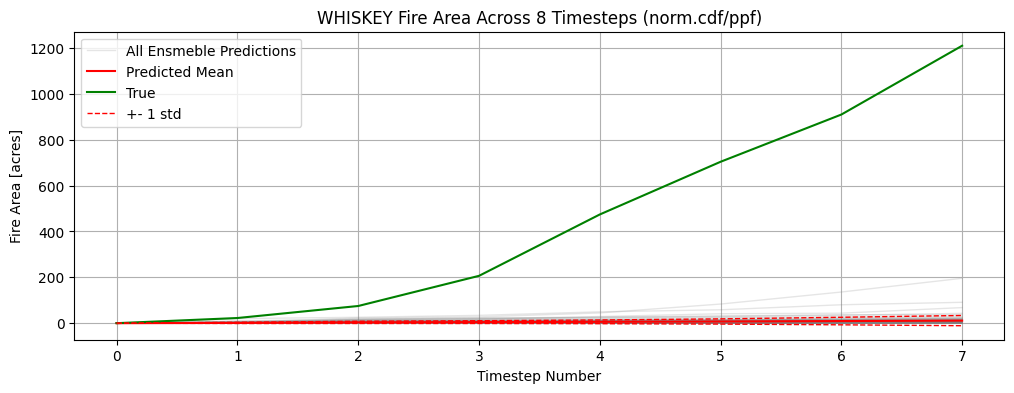

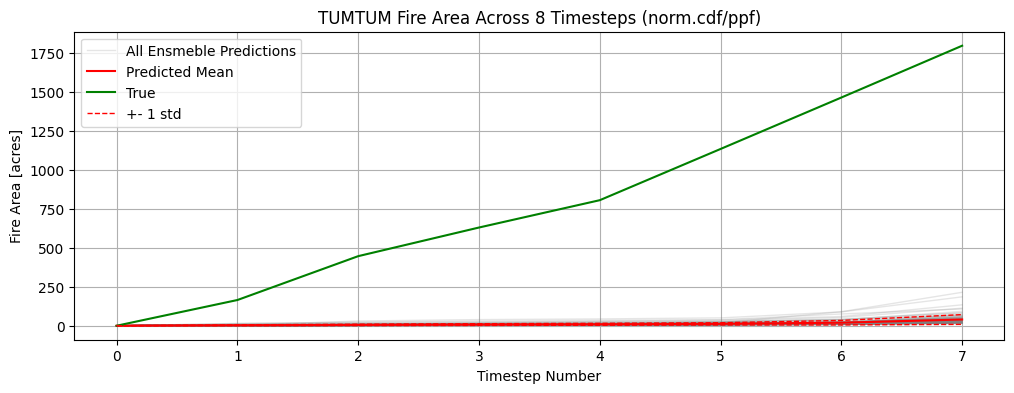

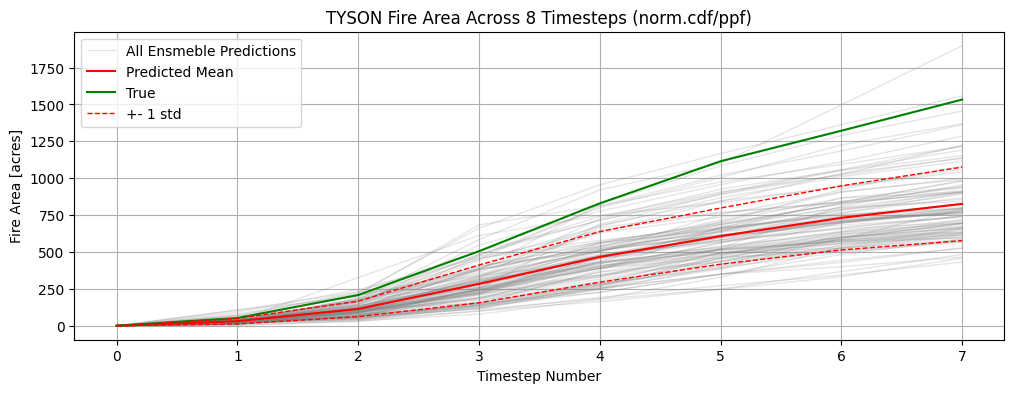

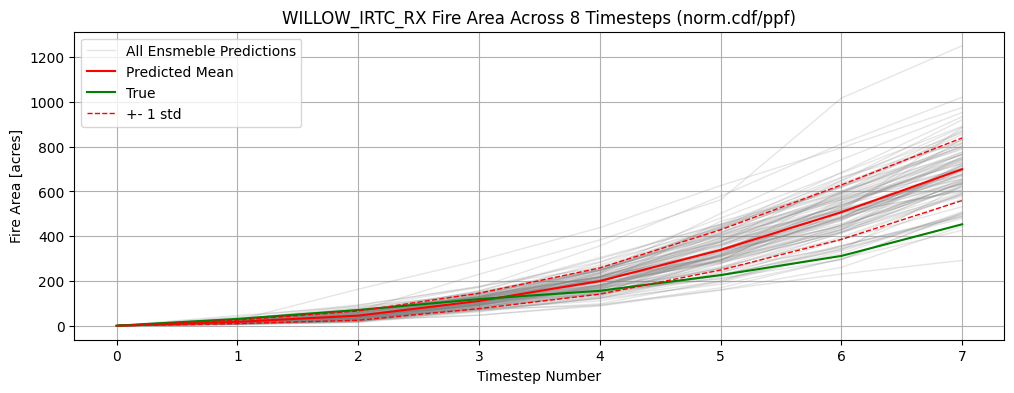

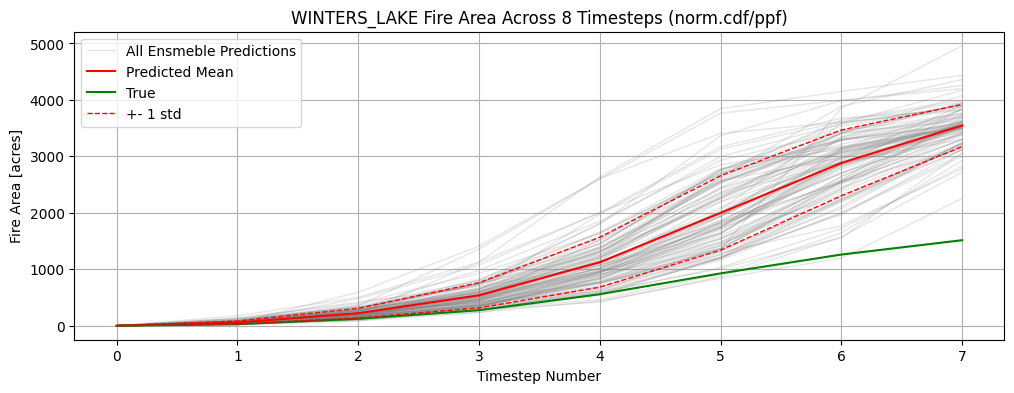

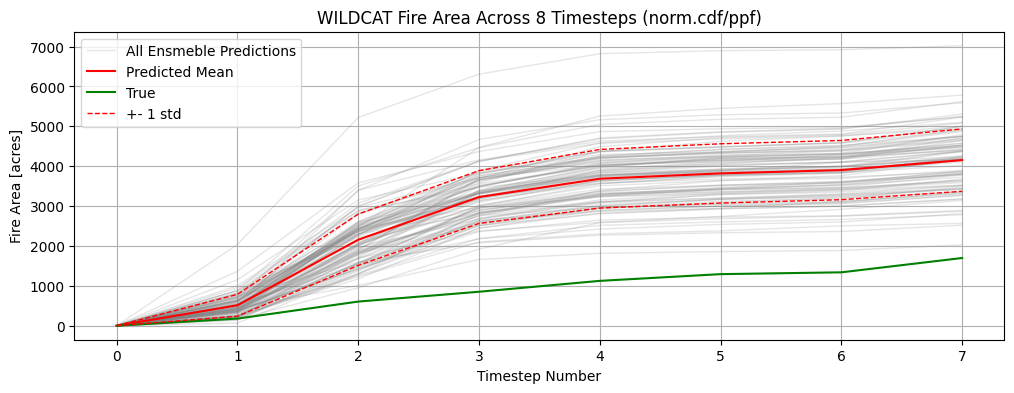

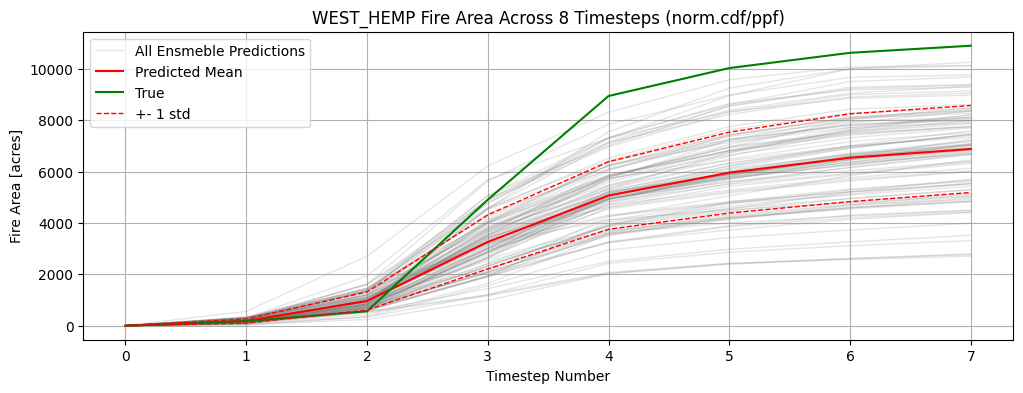

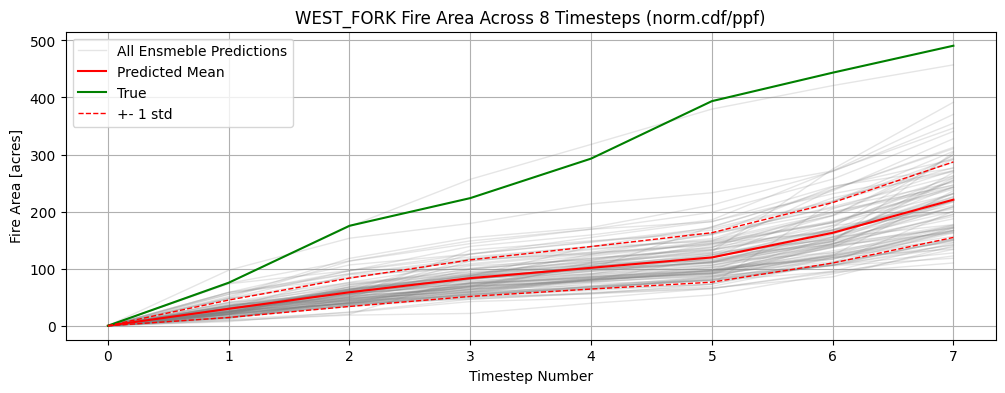

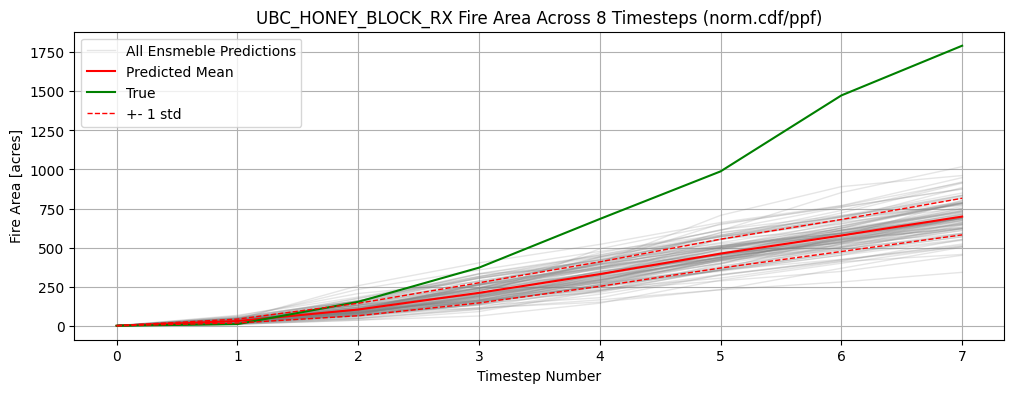

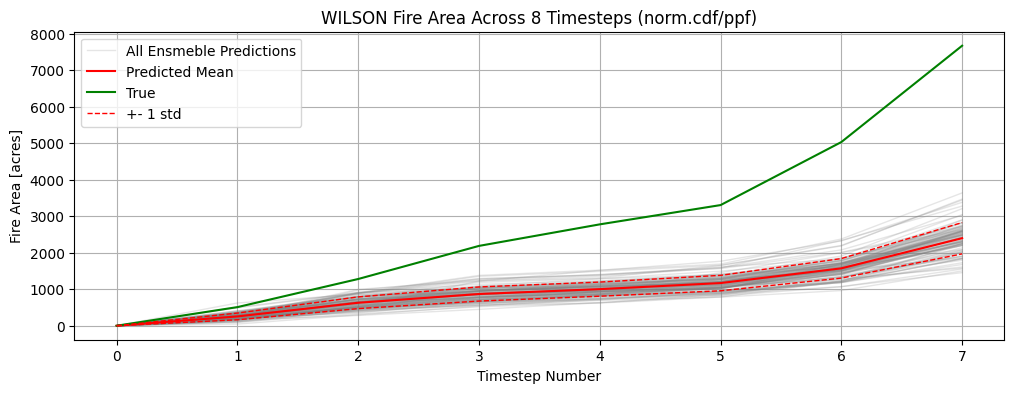

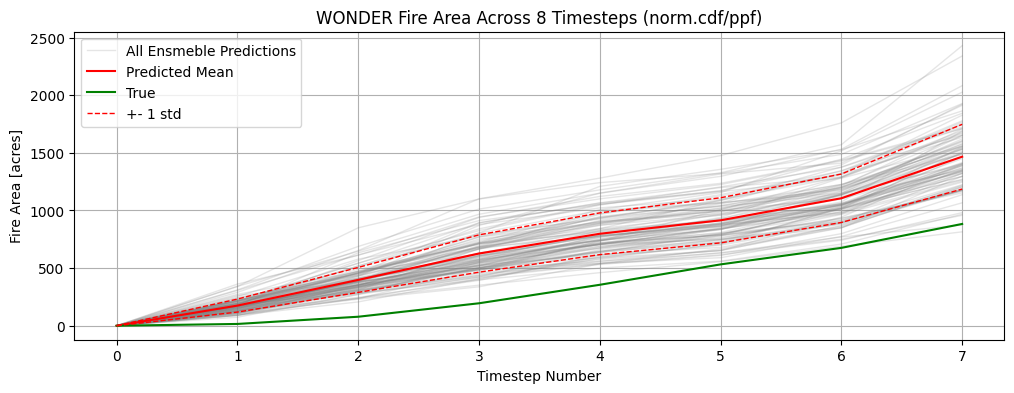

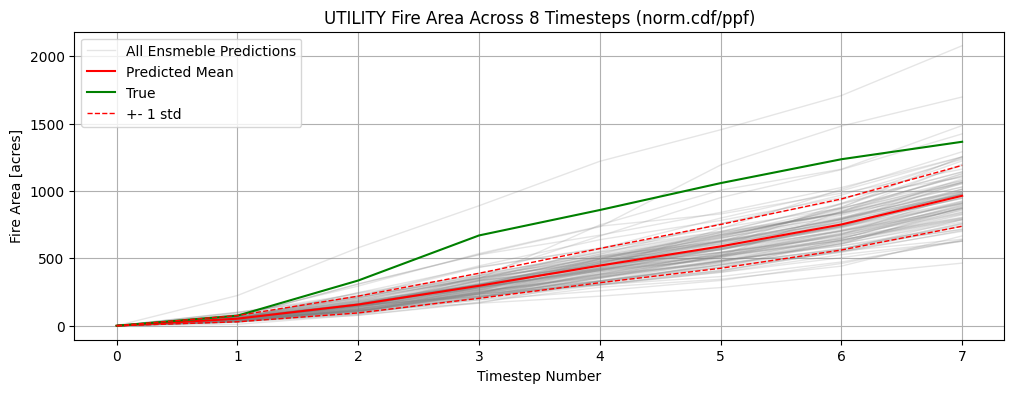

In [109]:
fires = ['WHISKEY', 'TUMTUM', 'TYSON', 'WILLOW_IRTC_RX', 'WINTERS_LAKE', 'WILDCAT', 'WEST_HEMP', 'WEST_FORK', 'UBC_HONEY_BLOCK_RX', 'WILSON', 'WONDER', 'UTILITY']
for fire_name in fires:
    fire_area_matrix = np.load(f'/Users/isaaclee/Wildfire_Research/multiple_recursive_wildfire_results/depth_4_epochs_10000_schedule_VE_sigma_2/{fire_name}_fire_area_matrix.npz')
    fire_area_growth_matrix = fire_area_matrix['arr_0']
    #print(fire_area_growth_matrix.shape)
    area = np.sum(fire_area_growth_matrix[:, :, 2], axis=0)
    #print(area)
    # print(f"Final predicted mean area: {np.mean(area)}")
    pred_area = np.mean(area)

    condition_matrix = np.load(f"/Users/isaaclee/Wildfire_Research/validation_case_data_and_preparation/test_fire_data_npy/{fire_name}_validation_case_data.npy")
    real_fire_area_growth = condition_matrix[:, 2]

    target_area = np.sum(real_fire_area_growth)
    # print(f"Target area: {target_area}")

    pred_fire_area = fire_area_growth_matrix.copy()
    mean_pred_fire_area = np.zeros(shape=(7))
    std_at_timestep = np.zeros(shape=(7))
    real_fire_area = real_fire_area_growth.copy()

    for i in range(1,7):
        pred_fire_area[i, :, 2] = fire_area_growth_matrix[i, :, 2] + pred_fire_area[i-1, :, 2]
        real_fire_area[i] = real_fire_area_growth[i] + real_fire_area[i-1]

    for i in range(0,7):
        mean_pred_fire_area[i] = np.mean(pred_fire_area[i, :, 2])
        std_at_timestep[i] = np.std(pred_fire_area[i, :, 2])

    zeros = np.zeros((1, 100, 3))
    pred_fire_area = np.concatenate((zeros, pred_fire_area), axis=0)
    pred_fire_area = pred_fire_area[:, :, 2]
    mean_pred_fire_area = np.insert(mean_pred_fire_area, 0, 0)
    std_at_timestep = np.insert(std_at_timestep, 0, 0)
    real_fire_area = np.insert(real_fire_area, 0, 0)

    # print(f"Real fire area {real_fire_area}")
    # print(f"Mean predicted fire area {mean_pred_fire_area}")

    area_plus_1std  = mean_pred_fire_area + std_at_timestep
    area_minus_1std = mean_pred_fire_area - std_at_timestep

    plt.figure(figsize=(12,4))
    plt.title(f'{fire_name} Fire Area Across 8 Timesteps (norm.cdf/ppf)')
    plt.xlabel('Timestep Number')
    plt.xticks(range(0, 8))
    plt.ylabel('Fire Area [acres]')
    plt.grid(True)
    for i in range(0,100):
        if i == 0:
            plt.plot(pred_fire_area[:, i], color='gray', alpha=0.2, linewidth=1, label='All Ensmeble Predictions')
        else:
            plt.plot(pred_fire_area[:, i], alpha=0.2, linewidth=1, color='gray')
    plt.plot(mean_pred_fire_area, color='red', label='Predicted Mean')
    plt.plot(real_fire_area, color='green', label='True')
    plt.plot(area_plus_1std, color='red', alpha=1, linewidth=1, linestyle='dashed', label='+- 1 std')
    plt.plot(area_minus_1std, color='red', alpha=1, linewidth=1, linestyle='dashed')
    plt.legend()
    plt.show()

In [110]:
fires = ['WHISKEY', 'TUMTUM', 'TYSON', 'WILLOW_IRTC_RX', 'WINTERS_LAKE', 'WILDCAT', 'WEST_HEMP', 'WEST_FORK', 'UBC_HONEY_BLOCK_RX', 'WILSON', 'WONDER', 'UTILITY']

x3_first_max = np.load('/Users/isaaclee/Wildfire_Research/recursive_data/first_x3_max.npy')
x3_min = np.load('/Users/isaaclee/Wildfire_Research/recursive_data/recursive_x3_min.npy')
x3_max = np.load('/Users/isaaclee/Wildfire_Research/recursive_data/recursive_x3_max.npy')

for fire in fires:
    raw = np.load(f'/Users/isaaclee/Wildfire_Research/multiple_recursive_wildfire_results/depth_4_epochs_10000_schedule_VE_sigma_2/{fire}_raw_samples.npz')['arr_0']
    mean_x3 = np.mean(raw[:, :, 2])
    x3_new = mean_x3 * (x3_max - x3_min) + x3_min
    physical = norm.cdf(x3_new) * x3_first_max
    print(f"{fire}: mean_raw={mean_x3:.4f}, x3_new={x3_new:.4f}, physical={physical:.2f} acres")

# raw = np.load(f'/Users/isaaclee/Wildfire_Research/multiple_recursive_wildfire_results/depth_4_epochs_10000_schedule_VE_sigma_2/{fire_name}_raw_samples.npz')['arr_0']
# print(f"{fire_name}: {raw[:,:,2]}")

WHISKEY: mean_raw=0.1403, x3_new=-4.0374, physical=0.35 acres
TUMTUM: mean_raw=0.1878, x3_new=-3.5040, physical=3.00 acres
TYSON: mean_raw=0.2827, x3_new=-2.4391, physical=96.43 acres
WILLOW_IRTC_RX: mean_raw=0.2740, x3_new=-2.5370, physical=73.23 acres
WINTERS_LAKE: mean_raw=0.3297, x3_new=-1.9117, physical=366.23 acres
WILDCAT: mean_raw=0.3324, x3_new=-1.8806, physical=393.14 acres
WEST_HEMP: mean_raw=0.3588, x3_new=-1.5847, physical=740.38 acres
WEST_FORK: mean_raw=0.2438, x3_new=-2.8750, physical=26.46 acres
UBC_HONEY_BLOCK_RX: mean_raw=0.2796, x3_new=-2.4740, physical=87.52 acres
WILSON: mean_raw=0.3199, x3_new=-2.0218, physical=282.97 acres
WONDER: mean_raw=0.3059, x3_new=-2.1791, physical=192.06 acres
UTILITY: mean_raw=0.2909, x3_new=-2.3474, physical=123.83 acres


In [111]:
columns = ['change1', 'change2', 'change3', 'curr', 'prev', 'u', 'v', 'rh', 't', 'x_grad', 'y_grad', 'ter_var', 'rms', 'f1', 'f2', 'f3', 'f4', 'f5', 'f6', 'f7', 'f8', 'f9', 'f10', 'f11', 'f12', 'f13', 'f14']

fire_name = "TUMTUM"
condition_matrix = np.load(f"/Users/isaaclee/Wildfire_Research/validation_case_data_and_preparation/test_fire_data_npy/{fire_name}_validation_case_data.npy")
conditions_df = pd.DataFrame(condition_matrix, columns=columns)

# unnormalize weather data

conditions_df['u']  = conditions_df['u']*27-13.5
conditions_df['v']  = conditions_df['v']*27-13.5

conditions_df

,change1,change2,change3,curr,prev,u,v,rh,t,x_grad,...,f5,f6,f7,f8,f9,f10,f11,f12,f13,f14
0,33.359227,82.008098,164.942842,0.0,0.0,2.266350,0.102349,0.664746,0.515581,0.6548,...,0.009811,0.0,0.0,0.3285,0.077522,0.422433,0.0,0.0,0.0,0.128211
1,88.957937,181.004692,281.236812,0.0,0.0,0.538377,1.318304,0.772553,0.465851,0.6548,...,0.009811,0.0,0.0,0.3285,0.077522,0.422433,0.0,0.0,0.0,0.128211
2,61.004141,120.463873,183.630187,0.0,0.0,0.428513,1.429683,0.859673,0.435270,0.6548,...,0.009811,0.0,0.0,0.3285,0.077522,0.422433,0.0,0.0,0.0,0.128211
3,61.313023,125.714863,175.290380,0.0,0.0,0.418837,0.945239,0.906621,0.425335,0.6548,...,0.009811,0.0,0.0,0.3285,0.077522,0.422433,0.0,0.0,0.0,0.128211
4,70.579475,191.197789,328.495717,0.0,0.0,0.799110,1.098398,0.844324,0.446152,0.6548,...,0.009811,0.0,0.0,0.3285,0.077522,0.422433,0.0,0.0,0.0,0.128211
5,134.981315,234.132349,329.885684,0.0,0.0,1.921682,1.678608,0.680391,0.498576,0.6548,...,0.009811,0.0,0.0,0.3285,0.077522,0.422433,0.0,0.0,0.0,0.128211
6,99.768798,196.139897,332.202297,0.0,0.0,2.899370,1.449502,0.571894,0.539219,0.6548,...,0.009811,0.0,0.0,0.3285,0.077522,0.422433,0.0,0.0,0.0,0.128211


In [112]:
conditions_df.iloc[:, 13:]

,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,f12,f13,f14
0,0.0,0.033522,0.0,0.0,0.009811,0.0,0.0,0.3285,0.077522,0.422433,0.0,0.0,0.0,0.128211
1,0.0,0.033522,0.0,0.0,0.009811,0.0,0.0,0.3285,0.077522,0.422433,0.0,0.0,0.0,0.128211
2,0.0,0.033522,0.0,0.0,0.009811,0.0,0.0,0.3285,0.077522,0.422433,0.0,0.0,0.0,0.128211
3,0.0,0.033522,0.0,0.0,0.009811,0.0,0.0,0.3285,0.077522,0.422433,0.0,0.0,0.0,0.128211
4,0.0,0.033522,0.0,0.0,0.009811,0.0,0.0,0.3285,0.077522,0.422433,0.0,0.0,0.0,0.128211
5,0.0,0.033522,0.0,0.0,0.009811,0.0,0.0,0.3285,0.077522,0.422433,0.0,0.0,0.0,0.128211
6,0.0,0.033522,0.0,0.0,0.009811,0.0,0.0,0.3285,0.077522,0.422433,0.0,0.0,0.0,0.128211


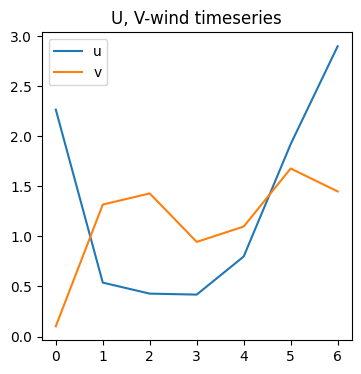

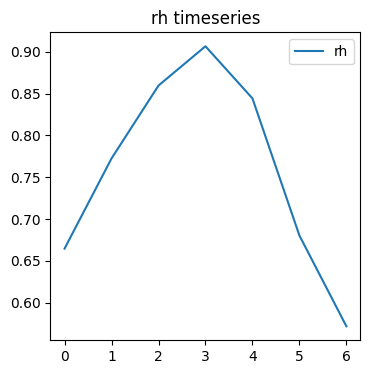

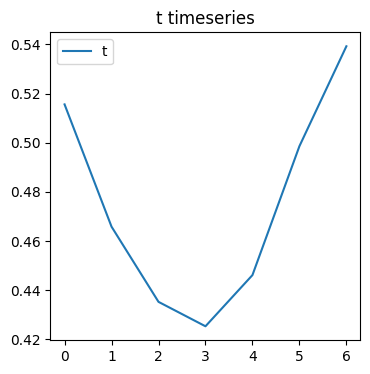

In [113]:
x=np.linspace(0,6,7)

plt.figure(figsize=(4,4))
plt.title('U, V-wind timeseries')
plt.plot(x, conditions_df['u'], label='u')
plt.plot(x, conditions_df['v'], label='v')
plt.legend()
plt.show()

plt.figure(figsize=(4,4))
plt.title('rh timeseries')
plt.plot(x, conditions_df['rh'], label='rh')
plt.legend()
plt.show()

plt.figure(figsize=(4,4))
plt.title('t timeseries')
plt.plot(x, conditions_df['t'], label='t')
plt.legend()
plt.show()